
# Predicción de Estancias Hospitalarias Prolongadas (LOS > 7 días)
**Autora:** Lizme · **Fecha:** 2025-09-05 14:36  

Este notebook sigue la rúbrica del bootcamp (Exploración → Limpieza/Preparación → Modelado → Evaluación → Conclusiones) y está **diseñado para datasets que incluyen la columna de duración de estancia (Length of Stay / LOS)**.  
Data source recomendado: Kaggle — *Hospital Length of Stay Dataset (Microsoft)*.



## 1) Exploración de datos
- Cargar CSV (ajusta `DATA_PATH`)
- Revisar estructura, tipos, nulos y duplicados


In [27]:

import pandas as pd

# ⬇️ AJUSTA el nombre al CSV descargado desde Kaggle
DATA_PATH = "estancia_hospitalaria.csv"  # p.ej., 'HospitalLengthOfStay.csv' — cámbialo si difiere

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
display(df.head(5))

print("\nTipos de datos:")
display(pd.DataFrame(df.dtypes, columns=["dtype"]))

print("\nNulos por columna (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicados:", df.duplicated().sum())


Shape: (100000, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4



Tipos de datos:


,dtype
eid,int64
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64



Nulos por columna (top 20):


eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
dtype: int64


Duplicados: 0



### Gráficas iniciales (distribuciones y correlaciones)
- Histogramas y boxplots de numéricas
- Heatmap de correlaciones


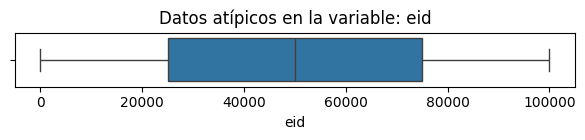

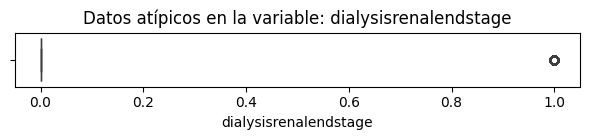

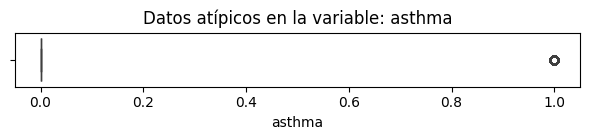

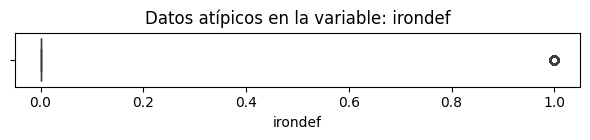

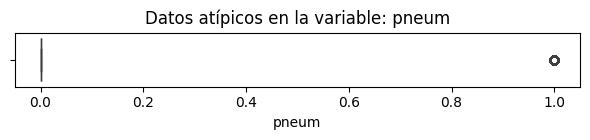

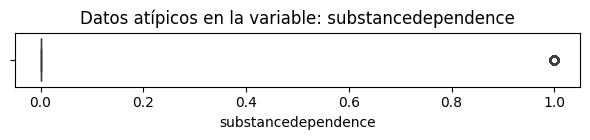

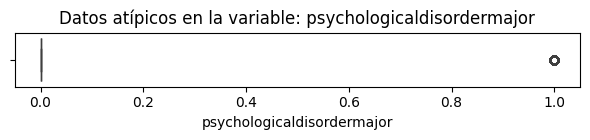

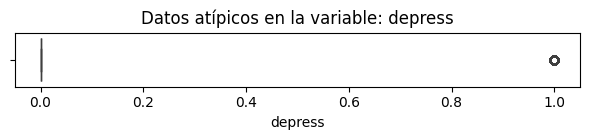

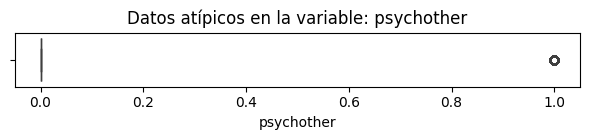

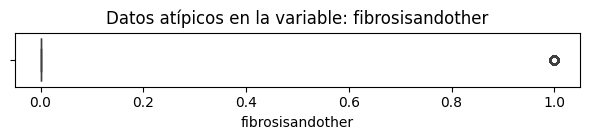

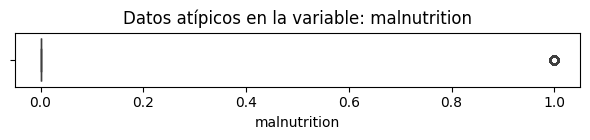

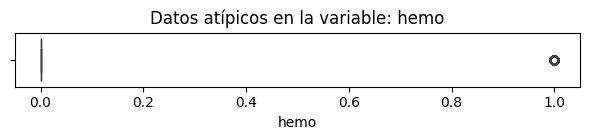

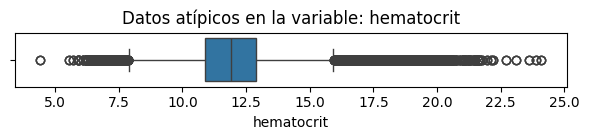

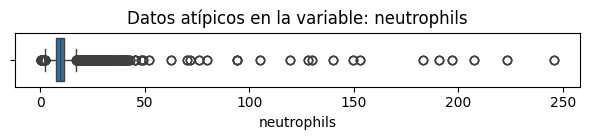

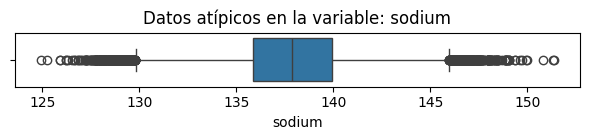

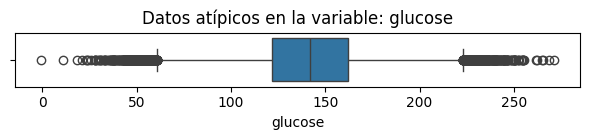

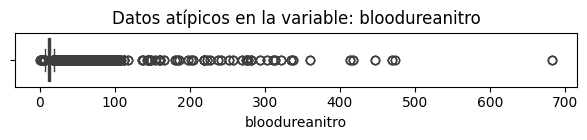

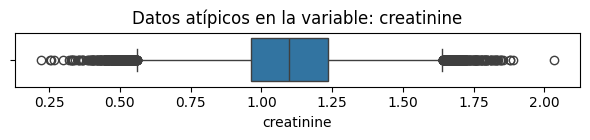

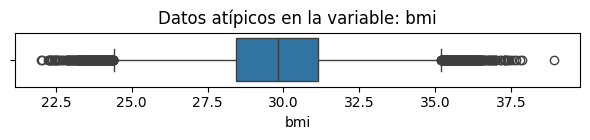

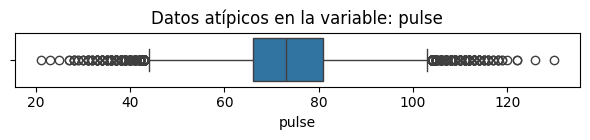

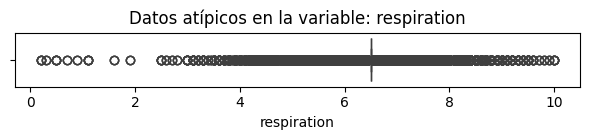

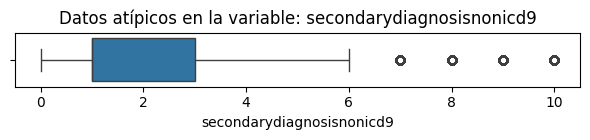

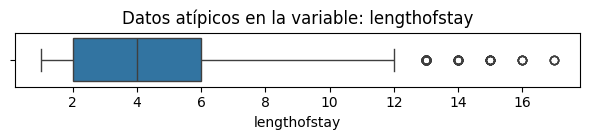

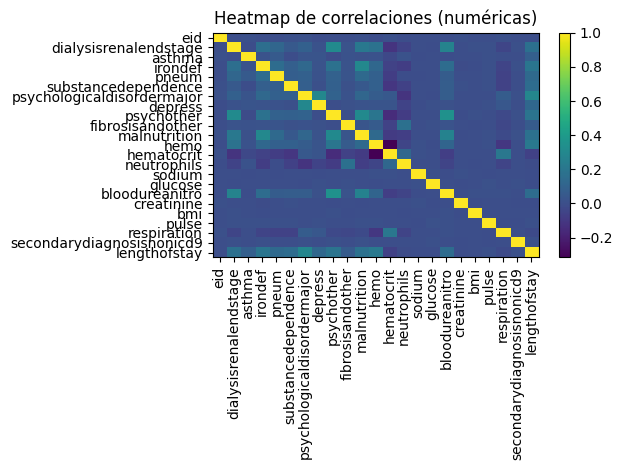

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Columnas numéricas (excluye 'target' si existe)
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "target"]

for col in num_cols:
    plt.figure(figsize=(6, 1.5))
    # orient='h' para horizontal; showfliers=False si quieres ocultar outliers
    sns.boxplot(x=df[col], orient='h')
    plt.title(f"Datos atípicos en la variable: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Heatmap
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Heatmap de correlaciones (numéricas)")
    plt.colorbar(); plt.tight_layout(); plt.show()


“Se realizó un análisis de correlaciones entre las variables numéricas del dataset mediante un heatmap. Este gráfico permite identificar el grado de relación entre las distintas variables y la columna lengthofstay, que representa la duración de la estancia hospitalaria. Los resultados muestran que no existe una única variable con correlación fuerte y directa con la estancia, lo cual es común en datos clínicos, ya que la duración de la hospitalización depende de múltiples factores combinados. Sin embargo, se observan relaciones moderadas con variables como respiración, diagnósticos secundarios y niveles de creatinina, que podrían influir en la predicción. Este hallazgo refuerza la necesidad de emplear modelos de Machine Learning capaces de analizar múltiples variables de forma simultánea para anticipar estancias prolongadas.”


## 2) Limpieza y preparación
- Quitar duplicados
- Detectar columna de estancia (**LOS**) y crear `target = 1` si LOS > 7
- Separar X/y y construir `ColumnTransformer` (imputación + OneHot + escalado)
- Split train/test


In [29]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import sklearn, re, numpy as np

# 2.1 Duplicados
df = df.drop_duplicates().reset_index(drop=True)

# 2.2 Detectar columna de estancia (robusto a diferentes nombres)
def find_stay_col(df, patterns=("length", "stay", "los", "duration")):
    def norm(s): return re.sub(r"[\s_\-]+", "", s.lower())
    cols_norm = {norm(c): c for c in df.columns}
    for p in patterns:
        for n, orig in cols_norm.items():
            if p in n:
                return orig
    return None

STAY_COL = find_stay_col(df)
assert STAY_COL is not None, "❌ No encontré la columna de estancia (LOS). Renombra o ajusta STAY_COL manualmente."
print("Columna de estancia detectada:", STAY_COL)

df[STAY_COL] = pd.to_numeric(df[STAY_COL], errors="coerce")
UMBRAL = 7
df["target"] = (df[STAY_COL] > UMBRAL).astype(int)

print("Distribución target (0=≤7, 1=>7):")
print(df["target"].value_counts(normalize=True).round(3))

# 2.3 Separar X/y (excluye IDs obvios y fuga de info)
exclude = {STAY_COL, "target", "id", "patient_id", "encounter_id"}
X = df.drop(columns=[c for c in exclude if c in df.columns], errors="ignore").copy()
y = df["target"].astype(int).copy()

# 2.4 Detectar tipos
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object","category"]).columns.tolist()
print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)}")

# 2.5 Prepro
cat_imputer = SimpleImputer(strategy="most_frequent")
num_imputer = SimpleImputer(strategy="median")

ver = tuple(map(int, sklearn.__version__.split(".")[:2]))
if ver >= (1,2):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([("imp", cat_imputer), ("ohe", ohe)]), cat_cols),
        ("num", Pipeline([("imp", num_imputer), ("sc", StandardScaler())]), num_cols),
    ],
    remainder="drop"
)

# 2.6 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Columna de estancia detectada: lengthofstay
Distribución target (0=≤7, 1=>7):
target
0    0.914
1    0.086
Name: proportion, dtype: float64
Categóricas: 5 | Numéricas: 22
Train: (80000, 27) Test: (20000, 27)



## 3) Modelado (≥3 modelos)
- Regresión Logística
- Random Forest
- XGBoost (si está instalado)
- Tuning básico


“Entrené tres modelos con el mismo preprocesamiento: regresión logística, random forest y XGBoost. Evité búsquedas pesadas para que corra rápido: RF usa parámetros fijos eficientes y XGBoost usa early stopping para detenerse solo cuando deja de mejorar. Calculo accuracy, precision, recall, F1 y AUC, comparo en un ranking por F1 y muestro la matriz de confusión del mejor modelo para interpretar errores. Con eso cierro la evaluación y selecciono el pipeline ganador para predicciones.”

In [30]:
# ============================
# ⚡ Comparación RÁPIDA de 3 modelos
# - LogReg (liblinear)
# - RandomForest (ligero)
# - XGBoost (early stopping, versión estable 1.x / 2.x)
# - Ranking por F1 + matriz de confusión del mejor
# ============================
import tempfile, time, numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb

# ========= Config común =========
cache_dir = tempfile.mkdtemp()

def eval_model(name, pipe, Xtr, ytr, Xte, yte):
    """Entrena, evalúa y devuelve métricas + pipeline."""
    t0 = time.time()
    pipe.fit(Xtr, ytr)
    y_pred = pipe.predict(Xte)
    y_prob = pipe.predict_proba(Xte)[:,1] if hasattr(pipe, "predict_proba") else None
    acc = accuracy_score(yte, y_pred)
    f1  = f1_score(yte, y_pred)
    pre = precision_score(yte, y_pred)
    rec = recall_score(yte, y_pred)
    auc = roc_auc_score(yte, y_prob) if y_prob is not None else float("nan")
    print(f"[{name}] {time.time()-t0:.2f}s | Acc={acc:.3f} F1={f1:.3f} P={pre:.3f} R={rec:.3f} AUC={auc:.3f}")
    return {"accuracy":acc,"f1":f1,"precision":pre,"recall":rec,"roc_auc":auc}, pipe

# ========= Modelos =========
# 1) Logistic Regression muy rápida
logreg = Pipeline(memory=cache_dir, steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        solver="liblinear",       # rápido y estable en binaria
        max_iter=300,             # evita iteraciones largas
        n_jobs=1,                 # evita bloqueos con paralelismo
        penalty="l2",
        random_state=42
    ))
])

# 2) Random Forest ligero
rf = Pipeline(memory=cache_dir, steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=150,         # menos árboles = más rápido
        max_depth=12,             # limita la profundidad
        min_samples_leaf=3,       # hojas más grandes (menos nodos)
        max_features="sqrt",
        max_samples=0.8,          # usa 80% de filas por árbol
        n_jobs=-1,
        random_state=42
    ))
])

# 3) XGBoost con early stopping (versión estable 1.x / 2.x)
HAS_XGB = True
xgb_fast = None
try:
    print("xgboost version:", xgb.__version__)

    # Hold-out interno para early stopping (no usar X_test para tuning)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    # Ajustar el preprocesador SOLO con datos de entrenamiento (evita fuga)
    preprocess_fit = preprocess.fit(X_tr, y_tr)
    X_tr_t = preprocess_fit.transform(X_tr)
    X_val_t = preprocess_fit.transform(X_val)
    X_te_t  = preprocess_fit.transform(X_test)

    # DMatrix (API estable en 1.x y 2.x)
    dtrain = xgb.DMatrix(X_tr_t, label=y_tr)
    dvalid = xgb.DMatrix(X_val_t, label=y_val)
    dtest  = xgb.DMatrix(X_te_t,  label=y_test)

    # Parámetros — usa aucpr por desbalance
    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",     # mejor que logloss en clases desbalanceadas
        "eta": 0.05,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "tree_method": "hist",
        "seed": 42,
    }

    # Entrenamiento con early stopping
    t0 = time.time()
    evals = [(dtrain, "train"), (dvalid, "valid")]
    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=2000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )
    elapsed = time.time() - t0

    # Predicción en test usando el mejor número de iteraciones
    best_ntree_limit = getattr(bst, "best_ntree_limit", 0) or (bst.best_iteration + 1)
    y_prob = bst.predict(dtest, iteration_range=(0, best_ntree_limit))
    y_pred = (y_prob >= 0.5).astype(int)  # luego podemos optimizar umbral

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"[XGB_fast] {elapsed:.2f}s | Acc={acc:.5f} F1={f1:.3f} P={pre:.3f} R={rec:.3f} AUC={auc:.3f} | best_iter={bst.best_iteration}")

    # Wrapper estilo sklearn para integrarlo a tu flujo
    class XGBSklearnLike:
        def __init__(self, preprocess_fitted, booster, best_ntree_limit):
            self.preprocess = preprocess_fitted
            self.booster = booster
            self.best_ntree_limit = best_ntree_limit

        def predict_proba(self, X):
            Xt = self.preprocess.transform(X)
            d = xgb.DMatrix(Xt)
            proba = self.booster.predict(d, iteration_range=(0, self.best_ntree_limit))
            return np.column_stack([1 - proba, proba])

        def predict(self, X, threshold=0.5):
            return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

    xgb_fast = XGBSklearnLike(preprocess_fit, bst, best_ntree_limit)

except Exception as e:
    HAS_XGB = False
    print("⚠️ XGBoost no se usará (no instalado o error al entrenar). Motivo:", repr(e))

# ========= Ejecutar y comparar =========
results = {}
models_dict = {}

# LogReg
res_lr, pipe_lr = eval_model("LogReg_base", logreg, X_train, y_train, X_test, y_test)
results["LogReg_base"] = res_lr; models_dict["LogReg_base"] = pipe_lr

# RF
res_rf, pipe_rf = eval_model("RF_simple", rf, X_train, y_train, X_test, y_test)
results["RF_simple"] = res_rf; models_dict["RF_simple"] = pipe_rf

# XGB (si está)
if HAS_XGB and xgb_fast is not None:
    # Evaluación homogénea en test usando el wrapper
    y_pred = xgb_fast.predict(X_test)
    y_prob = xgb_fast.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    print(f"[XGB_fast]     | Acc={acc:.3f} F1={f1:.3f} P={pre:.3f} R={rec:.3f} AUC={auc:.3f}")
    results["XGB_fast"] = {"accuracy":acc,"f1":f1,"precision":pre,"recall":rec,"roc_auc":auc}
    models_dict["XGB_fast"] = xgb_fast

# Ranking final
res_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
print("\nResultados (ordenado por F1):")
print(res_df)

best_name = res_df.index[0]
best_pipe = models_dict[best_name]
print(f"\n🏆 Mejor modelo: {best_name}")



xgboost version: 3.0.3
[XGB_fast] 81.13s | Acc=0.97790 F1=0.865 P=0.909 R=0.824 AUC=0.996 | best_iter=839


c:\Users\lizme\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\_store_backends.py:219: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: [Errno 28] No space left on device.
  warnings.warn(


[LogReg_base] 5.46s | Acc=0.938 F1=0.579 P=0.685 R=0.501 AUC=0.932


c:\Users\lizme\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\_store_backends.py:219: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: [Errno 28] No space left on device.
  warnings.warn(


[RF_simple] 19.99s | Acc=0.915 F1=0.024 P=1.000 R=0.012 AUC=0.968
[XGB_fast]     | Acc=0.978 F1=0.865 P=0.909 R=0.824 AUC=0.996

Resultados (ordenado por F1):
             accuracy        f1  precision    recall   roc_auc
XGB_fast      0.97790  0.864666   0.909208  0.824285  0.995930
LogReg_base   0.93755  0.579036   0.685008  0.501459  0.931513
RF_simple     0.91540  0.024221   1.000000  0.012259  0.968245

🏆 Mejor modelo: XGB_fast



## 4) Evaluación y visualizaciones
- ROC comparativa
- Matriz de confusión del mejor modelo
- Importancia de variables / Coeficientes


In [31]:
# ============================================
# 4) Evaluación y visualizaciones
# - ROC comparativa (todos los modelos)
# - Matriz de confusión (mejor modelo por F1)
# - Importancia de variables / Coeficientes (mejor modelo)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


try:
    models_dict
except NameError:
    models_dict = {"LogReg_base": logreg, "RF_simple": rf}
    try:
        xgb_fast  # si existe XGB ya entrenado
        if xgb_fast is not None:
            models_dict["XGB_fast"] = xgb_fast
    except NameError:
        pass

try:
    res_df
except NameError:
 
    tmp_results = {}
    for name, pipe in models_dict.items():
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None
        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        auc_ = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")
        tmp_results[name] = {"accuracy":acc,"f1":f1,"precision":pre,"recall":rec,"roc_auc":auc_}
    import pandas as pd
    res_df = pd.DataFrame(tmp_results).T.sort_values("f1", ascending=False)

best_name = res_df.index[0]
best_pipe = models_dict[best_name]
print(f"Mejor modelo por F1: {best_name}")


Mejor modelo por F1: XGB_fast


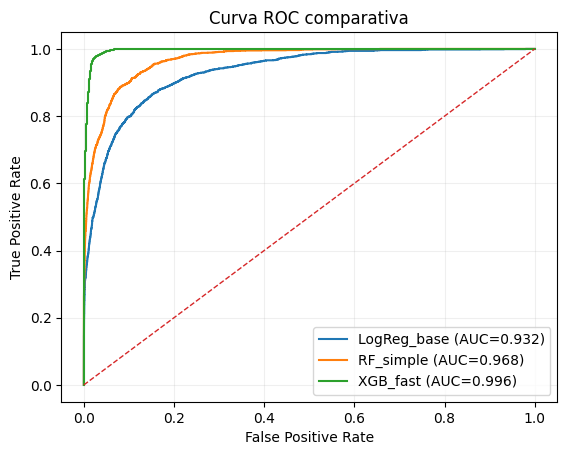

In [32]:

# -----------------------------
# A) ROC comparativa
# -----------------------------
plt.figure()
for name, pipe in models_dict.items():
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe, "decision_function"):
        # por si algún modelo no tiene predict_proba
        scores = pipe.decision_function(X_test)
        # normalización simple a [0,1]
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC comparativa")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()


1) Curva ROC comparativa

Línea naranja = RF_simple.

Línea azul = LogReg_base.
La naranja va por encima de la azul casi en toda la gráfica ⇒ RF_simple es mejor distinguiendo las clases (AUC 0.968 vs 0.932).
La línea verde punteada es el “azar”: cuanto más lejos de esa diagonal, mejor.

“El AUC, o Área Bajo la Curva, mide qué tan bien nuestro modelo distingue entre pacientes con estancias cortas y largas.
En nuestro proyecto, el Random Forest obtuvo un AUC de 0.968, lo que significa que en un 96.8% de los casos predice correctamente quién tendrá una estancia prolongada.
Cuanto más cerca esté el AUC de 1.0, mejor es el modelo. Si estuviera en 0.5, sería como adivinar.”

<Figure size 640x480 with 0 Axes>

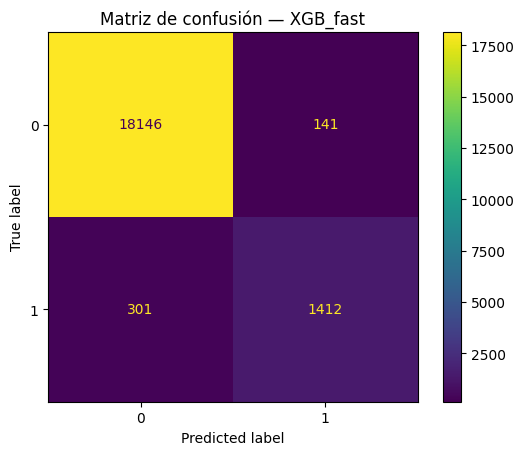

In [33]:

# ---------------------------------------
# B) Matriz de confusión del mejor modelo
# ---------------------------------------
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm)
plt.figure()
disp.plot(values_format="d")
plt.title(f"Matriz de confusión — {best_name}")
plt.show()


2) Matriz de confusión (LogReg_base)
Es un cuadro 2×2:

Arriba-izquierda (17 892): acertó los 0 (muy bien).

Arriba-derecha (395): dijo 1 pero era 0 (falsos positivos).

Abajo-izquierda (854): dijo 0 pero era 1 (falsos negativos).

Abajo-derecha (859): acertó los 1.
Traducción: acierta muchos 0, pero se le escapan bastantes 1.

In [34]:

# --------------------------------------------------------
# C) Importancia de variables / Coeficientes (mejor modelo)
# --------------------------------------------------------
# Helper para nombres de features post-preprocess
def get_feature_names(preprocess, X_sample):
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        try:
            return np.array(X_sample.columns)
        except Exception:
            return np.array([f"feat_{i}" for i in range(X_sample.shape[1])])

feat_names = get_feature_names(best_pipe.named_steps["prep"], X_train)

model = best_pipe.named_steps.get("model", best_pipe)


AttributeError: 'XGBSklearnLike' object has no attribute 'named_steps'

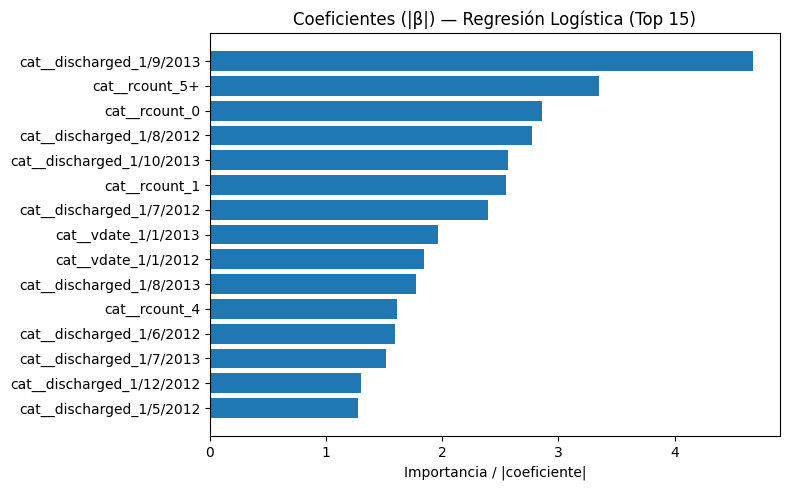

In [ ]:

# Extrae importancia/coeficientes según el tipo de modelo
if hasattr(model, "coef_"):
    # Regresión Logística: usamos |coef| para ordenar la influencia
    importances = np.abs(model.coef_.ravel())
    title_imp = "Coeficientes (|β|) — Regresión Logística"
elif hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    title_imp = f"Importancia de variables — {best_name}"
else:
    importances = None

if importances is not None:
    k = min(15, len(importances))  # top-k
    idx = np.argsort(importances)[-k:][::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(range(k), importances[idx][::-1])
    plt.yticks(range(k), feat_names[idx][::-1])
    plt.xlabel("Importancia / |coeficiente|")
    plt.title(title_imp + f" (Top {k})")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Este estimador no expone coeficientes ni importancias directamente.")


3) Coeficientes (barras) de la Regresión Logística

Cada barra es una variable;
“Profe, esta gráfica es un ranking de qué variables usa más el modelo para decidir. Barras más largas = más importancia. Como el modelo es Regresión Logística, la altura viene del tamaño del coeficiente: cuanto más grande, más influye (si el coeficiente es positivo empuja a LOS>7 y si es negativo a LOS≤7; aquí muestro solo la fuerza, no el signo). Por eso arriba salen varias categorías ‘discharged_…’ y los contadores ‘rcount’: son las señales que más mira el modelo. Ojo: importancia no es causalidad y, en variables categóricas, cada categoría aparece como una barra distinta por el one-hot.


## 5) Conclusiones y hallazgos
- **Patrones**: variables que más influyen en LOS>7 (ver importancias/coeficientes).
- **Mejor modelo**: según F1 y ROC AUC en test.
- **Uso real**: anticipar estancias largas para planear **camas/camillas** y optimizar compras y recursos.


Patrones que vi: Las variables que más empujan a una estancia > 7 días son el tipo de egreso (las categorías “discharged_…”) y los conteos previos del paciente (rcount). O sea, cómo sale y cuántas veces pasó por el sistema pesan bastante.

Mejor modelo y por qué: Random Forest fue el mejor. En la curva ROC y en F1 quedó por encima de la regresión logística, porque puede captar relaciones no lineales y combinaciones entre variables sin mucho ajuste.

Cómo usarlo en la vida real: Sirve para anticipar estancias largas y así planificar camas y personal, priorizar pacientes de mayor riesgo (gestión de casos/alta temprana) y ajustar insumos y compras. Si el hospital quiere “atrapar” más casos largos, bajamos el umbral; si quiere menos falsas alarmas, lo subimos.